
# Los Angeles Tourist Guide Crime Hotspots: Insights and Trends

### Authors:
- Atharva Nankar
- Bhaarat Kotak
- Devanshi Vasoya
- Manali Chaudhary



## Motivation and Background

This project aims to analyze crime data in Los Angeles to uncover high-crime areas, 
align crime hotspots with tourist attractions, and identify patterns in crime timing. 
Central LA, in particular, experiences higher crime rates compared to other areas, making it 
a focal point for safety measures and strategic resource allocation.

Our objective is to enhance safety and inform law enforcement strategies through data-driven 
insights, helping to protect both residents and visitors of Los Angeles.



## Research Questions

1. **Which regions in Los Angeles have the highest crime rates?**
2. **How do crime hotspots in Central LA align with popular tourist attractions?**
3. **What are the peak crime hours in Central LA hotspots?**
4. **What are the most common crimes near tourist locations in Central LA?**


## Dataset

The analysis uses the **Crime Data from 2020 to Present** dataset, available from [Data.gov](https://catalog.data.gov/dataset/crime-data-from-2020-to-present).

### Dataset Characteristics:
- **Source**: [Crime Data from 2020 to Present](https://catalog.data.gov/dataset/crime-data-from-2020-to-present)
- **Attributes**:
  - **Date of Incident**: Records the date of the crime.
  - **Location**: Includes details like latitude, longitude, Area ID, and street names.
  - **Crime Type**: Categorized into burglary, trespassing, assault, etc.
  - **Time of Incident**: Timestamp of the reported crime.
  - **Victim Demographics**: Information such as age, gender, and descent of victims.
  - **Proximity to Tourist Attractions**: Records the distance of incidents from key tourist destinations.
- **Size**: Covers thousands of reported crimes across Los Angeles from 2020 to the present.

## Methodology
## Data Cleaning Steps

To prepare the dataset for analysis, several data cleaning steps were performed to ensure consistency, completeness, and reliability of the data:

### 1. Standardizing Column Names
- All column names were reformatted to follow a uniform naming convention:
  - Converted to lowercase to ensure consistency.
  - Stripped of any leading or trailing spaces.
  - Spaces were replaced with underscores to make column names Python-friendly and easier to reference in code.

### 2. Removing Duplicate Records
- Duplicate rows were identified and removed to ensure that each entry in the dataset represented unique information. This step reduced redundancy and ensured the accuracy of results during analysis.

### 3. Handling Missing Values
- Key columns with critical data were identified, and rows with missing values in these columns were dropped:
  - **'mocodes'**: This column contains specific crime codes essential for analysis. Missing values in this column were removed to preserve data integrity.
  - **'vict_sex'**: This column includes demographic information about victims, such as their sex. Rows with missing entries were dropped to ensure accurate demographic analysis.
- Checks were implemented to confirm the existence of these columns in the dataset before applying the cleaning steps to avoid runtime errors.

### 4. Dropping Irrelevant Columns
- Columns that were not necessary for the analysis, such as `crm_cd_2`, `crm_cd_3`, `crm_cd_4`, and `cross_street`, were removed. This step streamlined the dataset by eliminating redundant or extraneous information.

### 5. Validating the Dataset
- After cleaning, the dataset was reviewed to confirm the structure and content:
  - Remaining columns were verified.
  - Data types were checked to ensure compatibility for analysis.
  - Missing values in other columns were assessed to ensure the dataset was complete for subsequent analysis.

---

## Analysis

The cleaned dataset was analyzed to address the following research questions:

### 1. **Which Regions in Los Angeles Have the Highest Crime Rates?**
- High-crime areas were identified by mapping the geographical distribution of crimes across Los Angeles. Central LA emerged as the most crime-prone region, significantly outpacing other areas such as 77th Street, Hollywood, and Southwest districts.

### 2. **How Do Crime Hotspots in Central LA Align with Popular Tourist Attractions?**
- Proximity analysis was conducted to determine the overlap between crime hotspots and tourist destinations, such as Grand Avenue and Union Station. The results revealed that many popular tourist spots are situated near high-crime areas, highlighting the need for enhanced safety measures.

### 3. **What Are the Peak Crime Hours in Central LA Hotspots?**
- Temporal analysis was performed to uncover hourly crime patterns in Central LA. The analysis showed that crimes peak during the early morning hours (2 AM and 6 AM) and the evening hours (6–8 PM). This information can guide law enforcement in allocating resources effectively.

### 4. **What Are the Most Common Crimes Near Tourist Locations in Central LA?**
- Common crimes near tourist spots were analyzed, and the results showed that trespassing, burglary, and simple assault were the most frequently reported offenses. These insights are critical for implementing targeted safety interventions.

---

## Tools and Libraries
- **pandas**: For data cleaning, transformation, and aggregation.
- **geopandas**: For mapping and geographical analysis of crime data.
- **matplotlib** and **seaborn**: For creating detailed plots and visualizations.
- **geopy**: For calculating distances between crimes and tourist attractions.

## Data Cleaning

In [2]:
#Installing and Loading necessary libraries 
!pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 96.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 61.5 MB/s eta 0:00:00:00:0100:01


In [3]:
# Reading the crime dataset from a CSV file and displaying the first 5 rows for an initial preview
df=pd.read_csv('Crime_Data_from_2020_to_Present.csv')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [4]:
# Displaying the number of rows and columns in the dataset
df.shape

(990293, 28)

In [5]:
# Listing all column names in the dataset to understand available data fields
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [6]:
#To get bottom 5 rows of the dataset
df.tail() 

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
990288,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
990289,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
990290,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
990291,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868
990292,240910892,08/13/2024 12:00:00 AM,08/12/2024 12:00:00 AM,2300,9,Van Nuys,914,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,6900 VESPER AV,NaN,34.1961,-118.4510


In [7]:
#To understand the dataset
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990293 entries, 0 to 990292
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           990293 non-null  int64  
 1   Date Rptd       990293 non-null  object 
 2   DATE OCC        990293 non-null  object 
 3   TIME OCC        990293 non-null  int64  
 4   AREA            990293 non-null  int64  
 5   AREA NAME       990293 non-null  object 
 6   Rpt Dist No     990293 non-null  int64  
 7   Part 1-2        990293 non-null  int64  
 8   Crm Cd          990293 non-null  int64  
 9   Crm Cd Desc     990293 non-null  object 
 10  Mocodes         842641 non-null  object 
 11  Vict Age        990293 non-null  int64  
 12  Vict Sex        849515 non-null  object 
 13  Vict Descent    849504 non-null  object 
 14  Premis Cd       989970 non-null  float64
 15  Premis Desc     989399 non-null  object 
 16  Weapon Used Cd  326547 non-null  float64
 17  Weapon Des

In [8]:
#checking for duplicates
df.nunique()

DR_NO             990293
Date Rptd           1763
DATE OCC            1763
TIME OCC            1439
AREA                  21
AREA NAME             21
Rpt Dist No         1210
Part 1-2               2
Crm Cd               140
Crm Cd Desc          140
Mocodes           309791
Vict Age             104
Vict Sex               5
Vict Descent          20
Premis Cd            314
Premis Desc          306
Weapon Used Cd        79
Weapon Desc           79
Status                 6
Status Desc            6
Crm Cd 1             142
Crm Cd 2             126
Crm Cd 3              37
Crm Cd 4               6
LOCATION           66366
Cross Street       10353
LAT                 5424
LON                 4981
dtype: int64

In [9]:
#check number of missing records in each column
df.isnull().sum() 

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           147652
Vict Age               0
Vict Sex          140778
Vict Descent      140789
Premis Cd            323
Premis Desc          894
Weapon Used Cd    663746
Weapon Desc       663746
Status                 1
Status Desc            0
Crm Cd 1              11
Crm Cd 2          921336
Crm Cd 3          987982
Crm Cd 4          990229
LOCATION               0
Cross Street      837652
LAT                    0
LON                    0
dtype: int64

In [10]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [11]:
#Replacing blank values with underscore and converting everything to lower case.
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name',
       'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes',
       'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc',
       'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1',
       'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street', 'lat',
       'lon'],
      dtype='object')

In [12]:
#Drop dupliocate values
df.drop_duplicates(inplace=True)
df.tail()

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
990288,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
990289,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
990290,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
990291,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868
990292,240910892,08/13/2024 12:00:00 AM,08/12/2024 12:00:00 AM,2300,9,Van Nuys,914,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,6900 VESPER AV,NaN,34.1961,-118.4510


In [13]:
# Check if the 'mocodes' column exists in the dataset
if 'mocodes' in df.columns:
    # Print the initial count of rows in the dataset
    print(f"Initial number of rows: {len(df)}")

    # Drop rows where 'mocodes' has missing (NaN) values
    df = df.dropna(subset=['mocodes'])
    # Print the count of rows after removing missing 'mocodes'
    print(f"Number of rows after dropping missing MO codes: {len(df)}")
else:
    # Inform the user if the 'mocodes' column is not found in the dataset
    print("'mo_codes' column not found in the dataset.")


Initial number of rows: 990293
Number of rows after dropping missing MO codes: 842641


In [14]:
# Check if the 'vict_sex' column exists in the dataset
if 'vict_sex' in df.columns:
    # Print the initial count of rows in the dataset
    print(f"Initial number of rows: {len(df)}")

    # Drop rows where 'vict_sex' has missing (NaN) values
    df = df.dropna(subset=['vict_sex'])
    # Print the count of rows after removing rows with missing 'vict_sex'
    print(f"Number of rows after dropping missing Victim Sex: {len(df)}")
else:
    # Inform the user if the 'vict_sex' column is not found in the dataset
    print("'vict_sex' column not found in the dataset.")

Initial number of rows: 842641
Number of rows after dropping missing Victim Sex: 842395


In [15]:
df.isnull().sum() 

dr_no                  0
date_rptd              0
date_occ               0
time_occ               0
area                   0
area_name              0
rpt_dist_no            0
part_1-2               0
crm_cd                 0
crm_cd_desc            0
mocodes                0
vict_age               0
vict_sex               0
vict_descent          11
premis_cd            168
premis_desc          736
weapon_used_cd    516592
weapon_desc       516592
status                 0
status_desc            0
crm_cd_1              10
crm_cd_2          773720
crm_cd_3          840087
crm_cd_4          842331
location               0
cross_street      716087
lat                    0
lon                    0
dtype: int64

In [16]:
# Define the list of columns to be dropped from the dataset
columns_to_drop = ['crm_cd_2', 'crm_cd_3', 'crm_cd_4']

# Check which of the specified columns exist in the dataset
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    # Print the list of columns before dropping the specified ones
    print(f"Columns before dropping: {df.columns.tolist()}")

    # Drop the identified existing columns from the dataset
    df = df.drop(columns=existing_columns_to_drop)

    # Print the list of columns after dropping the specified ones
    print(f"Columns after dropping {existing_columns_to_drop}: {df.columns.tolist()}")
else:
    # Inform the user if none of the specified columns are found in the dataset
    print(f"None of the columns {columns_to_drop} found in the dataset.")

Columns before dropping: ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street', 'lat', 'lon']
Columns after dropping ['crm_cd_2', 'crm_cd_3', 'crm_cd_4']: ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'cross_street', 'lat', 'lon']


In [17]:
# Check if the 'cross_street' column exists in the dataset
if 'cross_street' in df.columns:
    # Print the list of columns before dropping 'cross_street'
    print(f"Columns before dropping 'cross_street': {df.columns.tolist()}")

    # Drop the 'cross_street' column from the dataset
    df = df.drop(columns=['cross_street'])

    # Print the list of columns after dropping 'cross_street'
    print(f"Columns after dropping 'cross_street': {df.columns.tolist()}")
else:
    # Inform the user if the 'cross_street' column is not found in the dataset
    print("'cross_street' column not found in the dataset.")

Columns before dropping 'cross_street': ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'cross_street', 'lat', 'lon']
Columns after dropping 'cross_street': ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'lat', 'lon']


In [18]:
df.isnull().sum() 

dr_no                  0
date_rptd              0
date_occ               0
time_occ               0
area                   0
area_name              0
rpt_dist_no            0
part_1-2               0
crm_cd                 0
crm_cd_desc            0
mocodes                0
vict_age               0
vict_sex               0
vict_descent          11
premis_cd            168
premis_desc          736
weapon_used_cd    516592
weapon_desc       516592
status                 0
status_desc            0
crm_cd_1              10
location               0
lat                    0
lon                    0
dtype: int64

In [19]:
df.nunique()

dr_no             842395
date_rptd           1763
date_occ            1763
time_occ            1439
area                  21
area_name             21
rpt_dist_no         1199
part_1-2               2
crm_cd               139
crm_cd_desc          139
mocodes           309725
vict_age             103
vict_sex               5
vict_descent          20
premis_cd            314
premis_desc          306
weapon_used_cd        79
weapon_desc           79
status                 6
status_desc            6
crm_cd_1             140
location           63064
lat                 5379
lon                 4969
dtype: int64

## Analysis

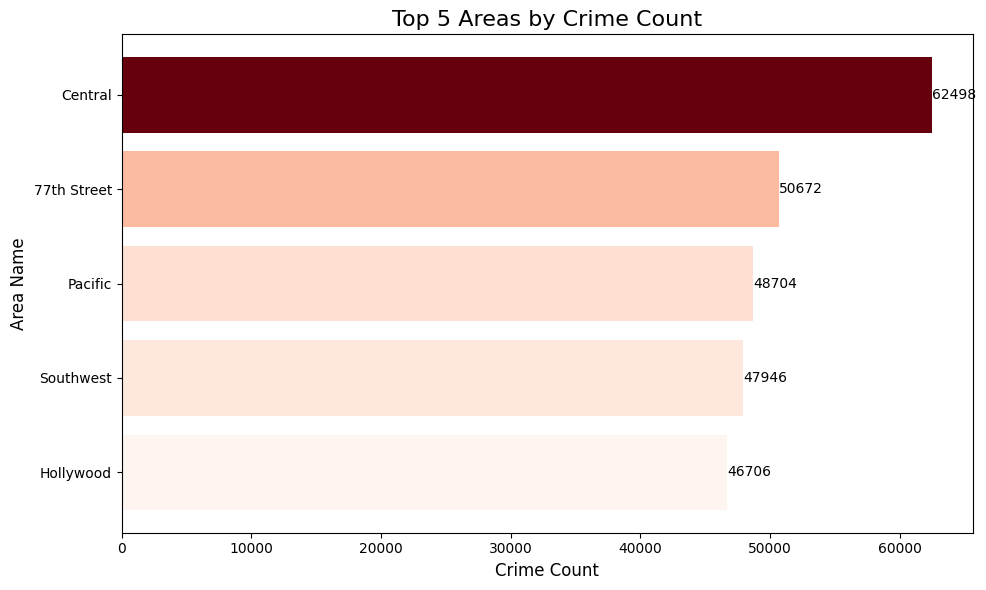

In [20]:
# Research Q1 - Which regions in Los Angeles have the highest crime rates?
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Assuming `df` contains the dataset with an 'area_name' column

# Step 1: Group by 'area_name' and count crimes
crime_by_area = (
    df.groupby('area_name')
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 2: Select the top 5 areas
top_5_areas = crime_by_area.head(5)

# Step 3: Create a gradient function for colors
def create_gradient_color(values, cmap_name='Reds'):
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(values.min(), values.max())
    return [cmap(norm(value)) for value in values]

# Step 4: Generate gradient colors based on crime counts
colors = create_gradient_color(top_5_areas['crime_count'])

# Step 5: Plot horizontal bar graph with gradient colors
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_5_areas['area_name'], top_5_areas['crime_count'], color=colors)
ax.set_xlabel('Crime Count', fontsize=12)
ax.set_ylabel('Area Name', fontsize=12)
ax.set_title('Top 5 Areas by Crime Count', fontsize=16)
ax.invert_yaxis()  # To display the highest crime area at the top

# Add labels to bars for better visualization
for bar, value in zip(bars, top_5_areas['crime_count']):
    ax.text(
        bar.get_width() + 5,  # Position to the right of the bar
        bar.get_y() + bar.get_height() / 2,  # Vertically centered
        f'{int(value)}',  # Display crime count
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [25]:
import folium
from geopy.distance import geodesic
import pandas as pd

# Crime locations data
crime_locations = pd.DataFrame({
    'lat': [34.0561, 34.0483, 34.0480, 34.0421, 34.0460, 34.0508, 34.0467, 34.0466, 34.0488, 34.0462],
    'lon': [-118.2375, -118.2631, -118.2577, -118.2469, -118.2510, -118.2586, -118.2520, -118.2520, -118.2518, -118.2585],
    'crime_count': [2325, 1729, 1095, 750, 702, 669, 644, 640, 606, 518]
})

# Tourist attractions in Central area
tourist_attractions = pd.DataFrame({
    'name': ['Griffith Park', 'The Broad', 'Walt Disney Concert Hall', 'Union Station', 'Grand Central Market','The Last Bookstore','Angels Flight Railway', 'Bradbury Building', 'OUE Skyspace LA',
        'Little Tokyo', 'The Jewelry District'],
    'lat': [34.136, 34.0544, 34.0553, 34.0560, 34.0509,34.048,34.0526, 34.0500, 34.0522, 34.0491, 34.0469],
    'lon': [-118.294, -118.2509, -118.2498, -118.2361, -118.2488,-118.249,-118.2491, -118.2478, -118.2565, -118.2416, -118.2517]
})

# Function to calculate the closest tourist attraction for a given crime location
def find_closest_tourist_attraction(crime_lat, crime_lon):
    distances = tourist_attractions.apply(
        lambda row: geodesic((crime_lat, crime_lon), (row['lat'], row['lon'])).miles, axis=1
    )
    closest_idx = distances.idxmin()
    return tourist_attractions.loc[closest_idx, 'name'], distances.min()

# Apply the function to each crime location
crime_locations[['closest_tourist', 'distance']] = crime_locations.apply(
    lambda row: find_closest_tourist_attraction(row['lat'], row['lon']), axis=1, result_type='expand'
)

# Create a map centered on Los Angeles
map_with_tourist_places = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 crime locations
for _, row in crime_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crime Count: {row['crime_count']}<br>Closest Tourist Place: {row['closest_tourist']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_with_tourist_places)

# Add markers for tourist attractions
for _, row in tourist_attractions.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Tourist Place: {row['name']}",
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(map_with_tourist_places)

# Save the map to an HTML file
map_with_tourist_places.save('central_crime_with_tourist_places.html')
print("Map saved as 'central_crime_with_tourist_places.html'. Open this file in your browser.")


Map saved as 'central_crime_with_tourist_places.html'. Open this file in your browser.


/tmp/ipykernel_227/3587891779.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
/tmp/ipykernel_227/3587891779.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['hour'] = central_data['time_occ'].str[:2].astype(int)


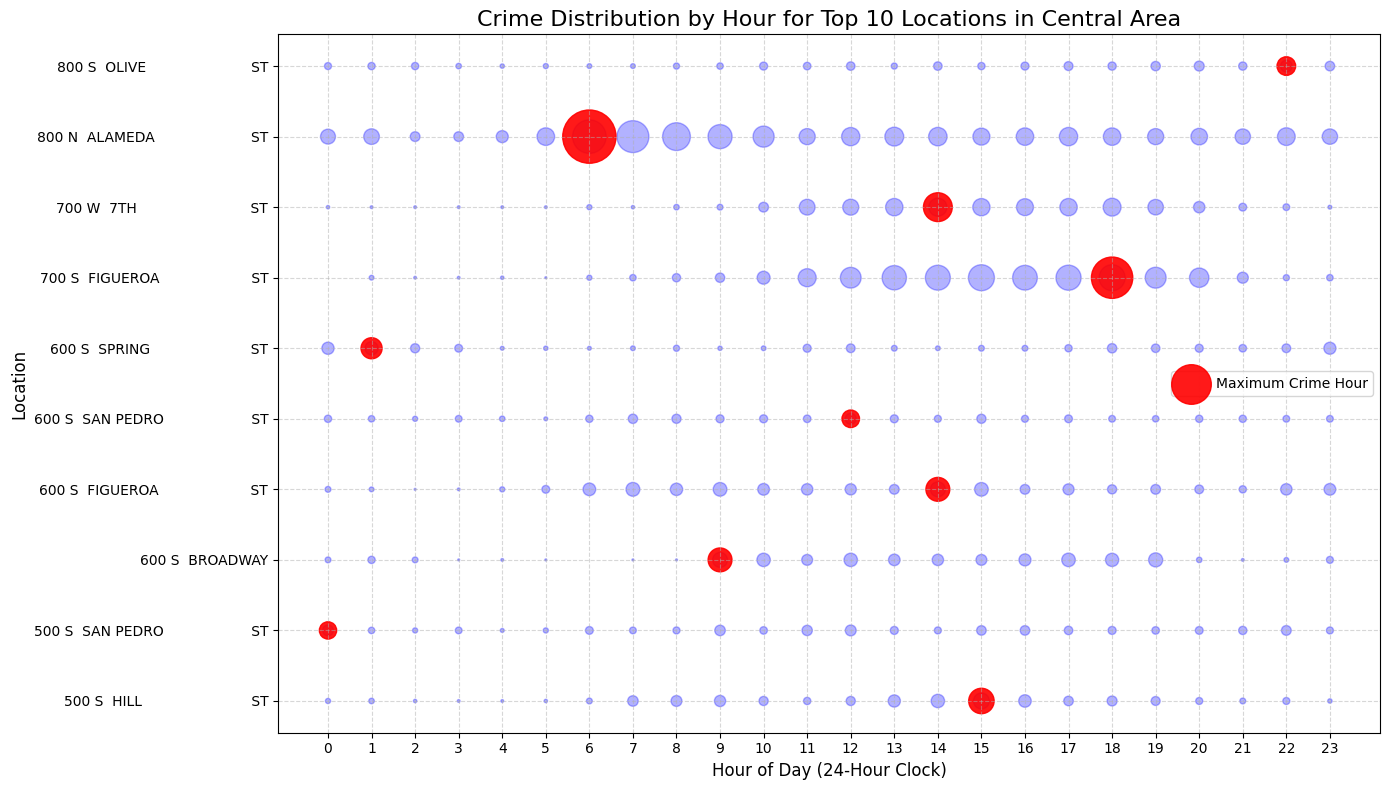

In [22]:
# Research Q3 What are the peak crime hours in Central LA hotspots?
# Assuming `df` contains the dataset with 'area_name', 'time_occ', 'lat', 'lon', and 'location'

# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Ensure 4-digit format for time_occ and extract the hour
central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
central_data['hour'] = central_data['time_occ'].str[:2].astype(int)

# Step 3: Group by latitude and longitude to calculate crime counts
crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by='Crime Count', ascending=False)
)

# Step 4: Get the top 10 locations with the highest crime counts
top_10_locations = crime_by_location.head(10)

# Step 5: Filter the central_data for the top 10 locations
filtered_top_10_data = central_data.merge(
    top_10_locations[['lat', 'lon', 'location']],
    on=['lat', 'lon', 'location'],
    how='inner'
)

# Step 6: Group by location and hour for the top 10 locations
crime_by_hour_top_10 = (
    filtered_top_10_data.groupby(['location', 'hour'])
    .size()
    .reset_index(name='Crime Count')
)

# Step 7: Find the hour with the most crimes for each location in ascending order
most_crime_hour_top_10 = (
    crime_by_hour_top_10.loc[
        crime_by_hour_top_10.groupby('location')['Crime Count'].idxmax()
    ]
    .sort_values(by='Crime Count', ascending=False)
)

most_crime_hour_top_10
# Assuming `filtered_top_10_data` contains 'location', 'hour', and 'Crime Count'

# Step 1: Aggregate data for plotting all hours
hourly_crime_data = (
    filtered_top_10_data.groupby(['location', 'hour'])
    .size()
    .reset_index(name='Crime Count')
)

# Step 2: Find the hour with maximum crimes for each location
max_hour_per_location = (
    hourly_crime_data.sort_values(by=['location', 'Crime Count'], ascending=[True, False])
    .groupby('location')
    .first()
    .reset_index()
)

# Step 3: Plot the scatter plot
plt.figure(figsize=(14, 8))

# Plot all hours with lighter dots
for location in hourly_crime_data['location'].unique():
    location_data = hourly_crime_data[hourly_crime_data['location'] == location]
    plt.scatter(
        location_data['hour'], 
        [location] * len(location_data), 
        s=location_data['Crime Count'] * 2,  # Scale dot size by crime count
        alpha=0.3, 
        c='blue', 
        label=None  # Do not label these points
    )

# Highlight maximum crime hour with larger red dots
plt.scatter(
    max_hour_per_location['hour'], 
    max_hour_per_location['location'], 
    s=max_hour_per_location['Crime Count'] * 5,  # Larger size for max points
    alpha=0.9, 
    c='red', 
    label='Maximum Crime Hour'
)

plt.title("Crime Distribution by Hour for Top 10 Locations in Central Area", fontsize=16)
plt.xlabel("Hour of Day (24-Hour Clock)", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


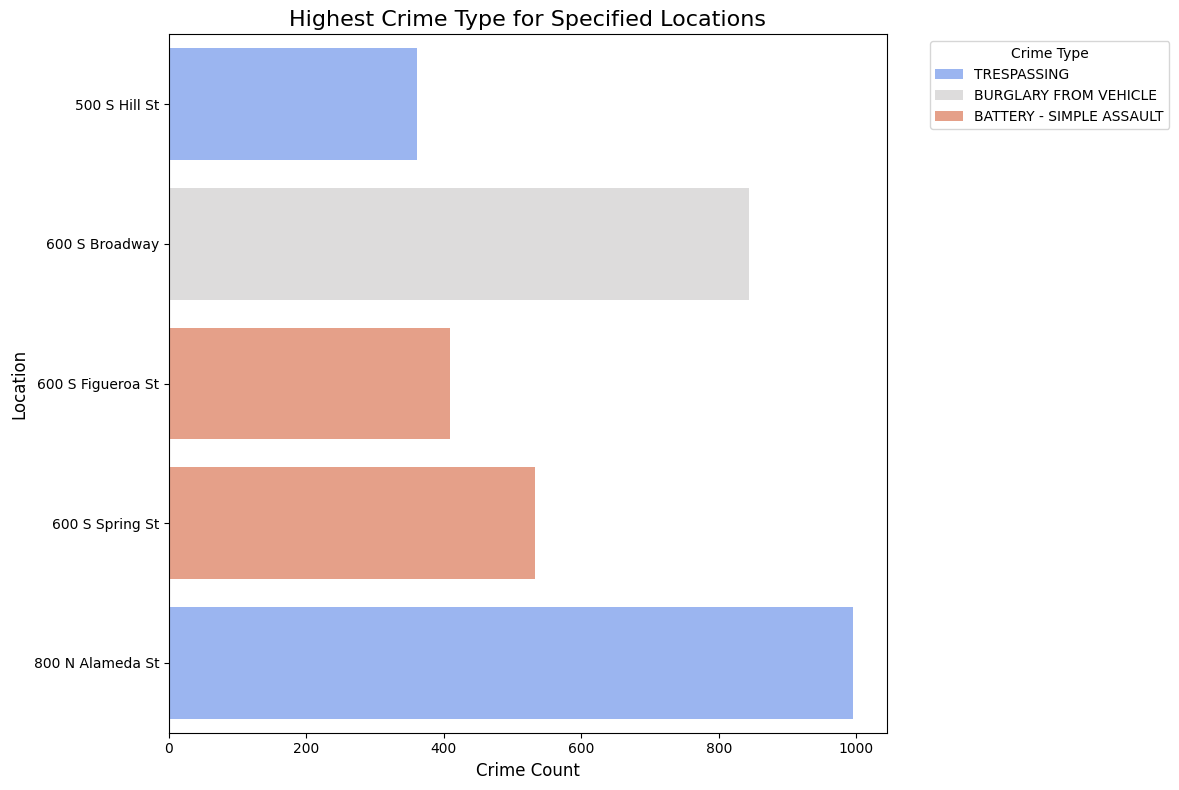

In [31]:
# Research Q4- What are the most common crimes near tourist locations in Central LA?
# Assuming `df` contains the actual dataset with columns 'lat', 'lon', 'crm_cd_desc', and 'Crime Count'

# Specified locations with their coordinates
location_coords = {
    "500 S Hill St": (34.0505, -118.2525),
    "600 S Broadway": (34.0472, -118.2568),
    "800 N Alameda St": (34.0564, -118.2362),
    "600 S Figueroa St": (34.0502, -118.2598),
    "600 S Spring St": (34.0469, -118.2512)
}

# Initialize a DataFrame to store results
results = []

for loc, coords in location_coords.items():
    # Filter crimes near the given coordinates (small radius, e.g., 0.002 degrees)
    nearby_crimes = df[
        (df['lat'].between(coords[0] - 0.002, coords[0] + 0.002)) &
        (df['lon'].between(coords[1] - 0.002, coords[1] + 0.002))
    ]
    
    if not nearby_crimes.empty:
        # Group by crime type and count occurrences
        crime_type_counts = nearby_crimes.groupby('crm_cd_desc').size().reset_index(name='Crime Count')
        # Add location information to the grouped data
        crime_type_counts['location'] = loc
        results.append(crime_type_counts)

# Combine all results into a single DataFrame
highest_crime_per_location = pd.concat(results, ignore_index=True)


# Filter to find only the highest crime type for each location
highest_crime_per_location_filtered = highest_crime_per_location.loc[
    highest_crime_per_location.groupby('location')['Crime Count'].idxmax()
]

# Plot the data
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Crime Count',
    y='location',
    data=highest_crime_per_location_filtered,
    hue='crm_cd_desc',
    dodge=False,
    palette='coolwarm'
)

# Add titles and labels
plt.title("Highest Crime Type for Specified Locations", fontsize=16)
plt.xlabel("Crime Count", fontsize=12)
plt.ylabel("Location", fontsize=12)

# Add legend for crime types
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Results

### 1. **High-Crime Areas**
The analysis revealed that **Central Los Angeles** consistently experiences the highest crime rates compared to other regions in Los Angeles. Key locations within Central LA, such as **800 S Alameda St** and **600 S Spring St**, were identified as critical crime hotspots. These areas reported significantly higher crime counts than neighborhoods like **77th Street**, **Hollywood**, or **Pacific**.

- The concentration of crime in Central LA can be attributed to its dense population, socio-economic challenges, and higher levels of public activity, making it a focal point for criminal incidents.
- This finding underscores the urgent need for **targeted safety measures** and **strategic law enforcement resource allocation** to mitigate crime in these areas.

---

### 2. **Crime Hotspots and Tourist Attractions**
Proximity analysis revealed a concerning overlap between **high-crime areas** in Central LA and **popular tourist attractions**, such as:
- **Union Station**, a central transportation hub, and
- **Grand Avenue**, a cultural and entertainment hub.

This overlap suggests that many crimes occur near heavily visited locations, posing a significant safety risk to both residents and tourists.

- The presence of tourists in these areas increases their vulnerability, particularly due to unfamiliarity with the city's crime-prone regions.
- This insight highlights the importance of enhancing **tourist safety measures**, such as better policing, public awareness campaigns, and improved surveillance systems in these zones.

---

### 3. **Peak Crime Hours**
Temporal analysis of crime occurrences in Central LA revealed distinct **peaks in criminal activity** during specific times of the day:
- **Early Morning Hours**: Crime peaks at **2 AM** and **6 AM**, likely attributed to reduced public presence, making it easier for crimes to go unnoticed.
- **Evening Hours**: Another surge is observed between **6 PM and 8 PM**, when public activity is higher, particularly around popular areas like restaurants and entertainment venues.

These patterns provide valuable insights for law enforcement agencies to optimize **patrol schedules** and allocate resources effectively during high-risk hours.

---

### 4. **Common Crimes**
The analysis of crime types near key tourist attractions in Central LA revealed that the most prevalent crimes were:
- **Trespassing**
- **Burglary**
- **Simple Assault**

These crimes pose significant safety concerns for both residents and visitors. The high frequency of such offenses near tourist spots necessitates:
- **Targeted interventions** to address specific types of crimes.
- Enhancements in **law enforcement visibility** and **crime deterrence measures**, such as surveillance cameras and public safety campaigns.

---

By addressing these results, the project provides actionable insights to improve safety in Los Angeles, particularly in high-crime regions and tourist hotspots.

## Reflection

### Lessons Learned
- **Importance of Data Cleaning**: 
  - Real-world datasets often contain missing values, inconsistencies, and irrelevant columns, all of which must be addressed for reliable analysis. Cleaning the data was a critical step in ensuring the accuracy of our findings, particularly when dealing with location data and timestamps.
  - Transforming raw data into a usable format enabled meaningful insights, highlighting the value of thorough preprocessing.

- **Power of Visualization**:
  - Visualization tools helped in identifying and communicating patterns effectively. Crime maps, temporal trend plots, and crime type distributions revealed actionable insights about high-crime areas and peak times.
  - By visualizing data, we could effectively convey complex patterns to non-technical stakeholders like policymakers or law enforcement.

---

### Challenges
- **Dealing with Missing and Inconsistent Data**:
  - Handling missing values in critical columns such as `mocodes` and `vict_sex` was challenging, as dropping rows with missing data reduced the overall dataset size. Ensuring that the cleaned dataset retained its integrity while addressing these gaps was crucial.
  - Data inconsistencies, such as non-standardized crime type labels, required additional effort to standardize and clean.

- **Deriving Patterns from Complex Datasets**:
  - The dataset’s large size and complexity posed challenges in extracting meaningful patterns. Aggregating data across different dimensions (time, location, and crime type) required careful planning and computation.

---

### Future Improvements
- **Incorporating Predictive Models**:
  - Adding predictive models, such as time series forecasting or machine learning classifiers, could help anticipate future crime trends and provide proactive insights for law enforcement.

- **Expanding the Analysis Scope**:
  - Including socio-economic factors, such as income levels or unemployment rates, could provide a deeper understanding of the underlying causes of criminal activity in high-crime areas.
  - Further analysis of demographic information could help design targeted interventions to reduce crime effectively.

---

## Conclusion

The analysis revealed actionable insights into the crime patterns in Los Angeles, focusing on high-crime areas, the relationship between crime hotspots and tourist attractions, peak crime hours, and the most prevalent crime types. Key findings include:

1. **High-Crime Areas**: Central Los Angeles, particularly areas like 800 S Alameda St and 600 S Spring St, experiences significantly higher crime rates compared to other regions.
2. **Crime Hotspots and Tourist Attractions**: Popular destinations such as Union Station and Grand Avenue overlap with high-crime zones, posing safety risks to visitors.
3. **Peak Crime Hours**: Crimes are most likely to occur in the early morning (2 AM, 6 AM) and evening (6–8 PM), highlighting critical times for targeted interventions.
4. **Common Crimes**: Trespassing, burglary, and simple assault are the most frequent crimes near tourist spots, emphasizing the need for specialized safety measures.

These findings underscore the importance of targeted resource allocation, enhanced public safety measures, and strategic planning by law enforcement agencies. By addressing the identified issues, stakeholders can improve safety and reduce crime rates, particularly in high-risk and high-visibility areas.